<a href="https://colab.research.google.com/github/shivanshsingh-123/CODSOFT-INTERNSHIP/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

df= pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

Saving creditcard.csv to creditcard (1).csv
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("\nNull Values")
print(df.isnull().sum())

df = df.dropna()

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Clean Dataset Shape:", df.shape)


Null Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Rows
1081
Clean Dataset Shape: (283726, 31)


In [ ]:
df['high_amount'] = (df['Amount'] > 3000).astype(int)

In [ ]:
cols_to_drop = [
    'transaction_id','account_number',
    'first_name','last_name',
    'latitude','longitude','dob'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print("After preprocessing:", df.shape)

After preprocessing: (283726, 32)


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

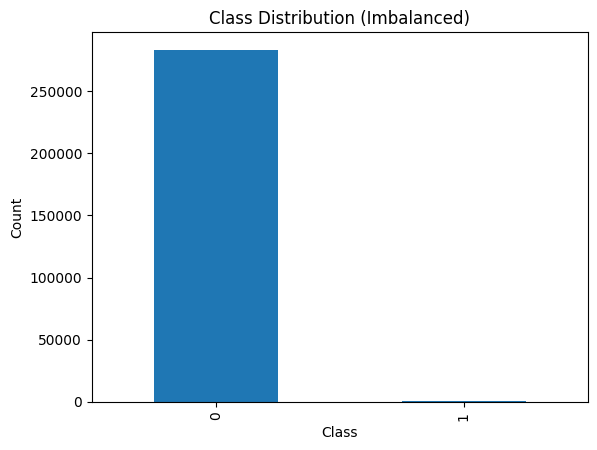

Class Ratio:
 Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Class Ratio:\n", df['Class'].value_counts(normalize=True))

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve, classification_report

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

# ================= MODELS =================
models = {
    "Logistic": LogisticRegression(max_iter=400),

    "Decision Tree": DecisionTreeClassifier(max_depth=6),

    "Random Forest": RandomForestClassifier(
      n_estimators=100,
      max_depth=8,
      class_weight="balanced"
      ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        gamma=1,
        min_child_weight=5,
        eval_metric='logloss',
        random_state=42
    )
}

# ================= RESULTS STORAGE =================
results = {
    "Model": [],
    "Recall": [],
    "Precision": [],
    "F1 Score": [],
    "ROC-AUC": []
}

best_model = None

# For ROC curve plotting
roc_data = {}

# ================= TRAINING LOOP =================
for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test)[:,1]

    # threshold tuning
    y_pred = (y_prob > 0.2).astype(int)

    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("Recall:", rec)
    print("Precision:", prec)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)

    results["Model"].append(name)
    results["Recall"].append(rec)
    results["Precision"].append(prec)
    results["F1 Score"].append(f1)
    results["ROC-AUC"].append(auc)

    # store ROC curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    if name == "XGBoost":
        best_model = model


Training Logistic...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Recall: 0.8631578947368421
Precision: 0.03426661094860008
F1 Score: 0.06591639871382636
ROC-AUC: 0.953107345157655

Training Decision Tree...
Recall: 0.8631578947368421
Precision: 0.029948867786705625
F1 Score: 0.05788916343099188
ROC-AUC: 0.9430933072208508

Training Random Forest...
Recall: 0.8736842105263158
Precision: 0.06634692246203037
F1 Score: 0.12332838038632987
ROC-AUC: 0.968350259065432

Training XGBoost...
Recall: 0.8947368421052632
Precision: 0.030564545127651922
F1 Score: 0.05910987482614743
ROC-AUC: 0.9630444578021107


In [ ]:
results_df = pd.DataFrame(results)

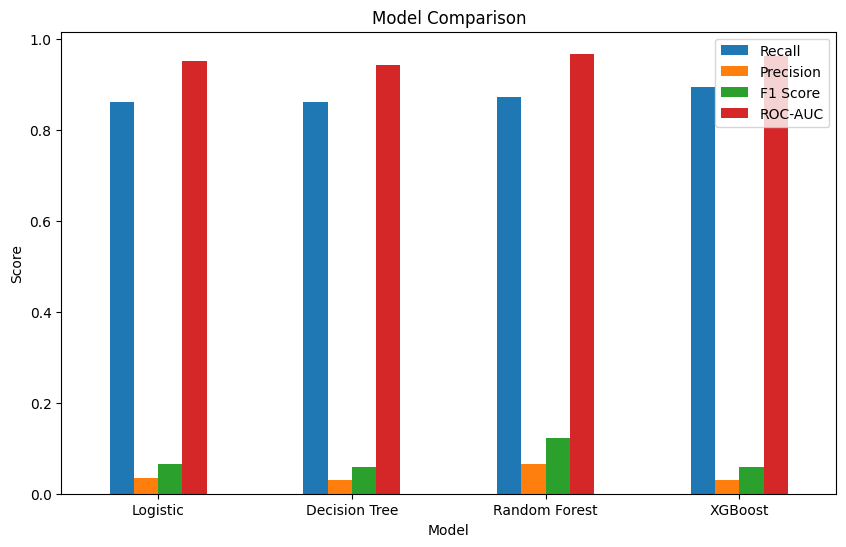

In [ ]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

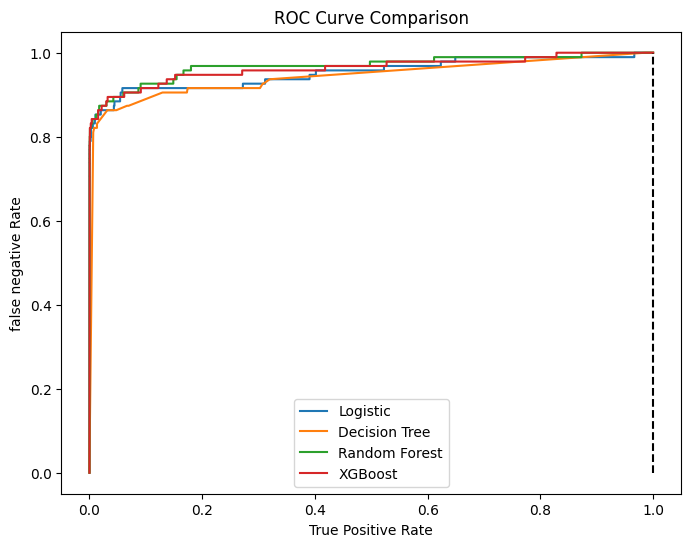

In [ ]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([1,1],[0,1],'k--')  # diagonal
plt.xlabel("True Positive Rate")
plt.ylabel("false negative Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

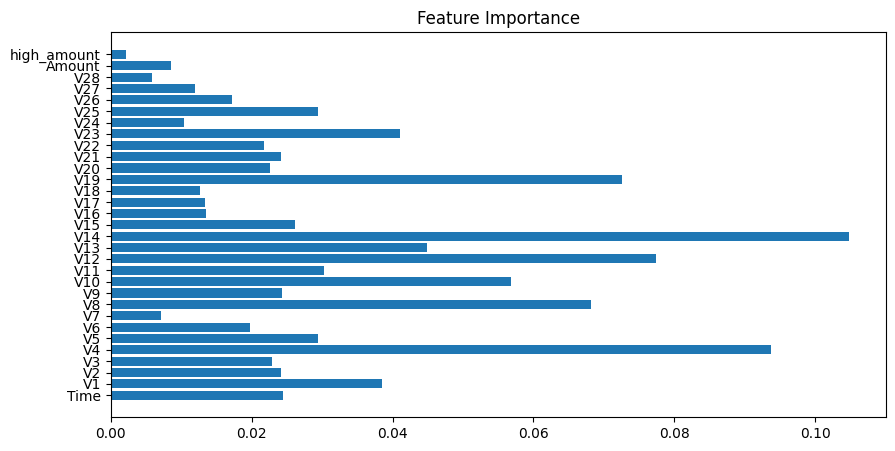

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")
model = best_model

In [ ]:
%%writefile app.py

# =========================
# IMPORTS
# =========================
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle

# =========================
# PAGE CONFIG (WHITE UI)
# =========================
st.set_page_config(page_title="Fraud Detection", layout="centered")

# Custom CSS for clean white UI
st.markdown("""
<style>
body {
    background-color: white;
}
.big-text {
    font-size: 32px !important;
    font-weight: bold;
    text-align: center;
}
.footer {
    bottom: 10px;
    width: 100%;
    text-align: center;
    font-size: 16px;
    color: white;
}
</style>
""", unsafe_allow_html=True)

# =========================
# FOOTER FUNCTION
# =========================
def footer():
    st.markdown("""
    <div class="footer">
    DIT University , Dehradun | Final-Year Capstone Project ( BTIT-08 ) <br>
    Saksham Patwal | Subham Singh | Aman Raj <br>
    1000018319 | 1000017792 | 1000017798
    </div>
    """, unsafe_allow_html=True)

# =========================
# LOGIN SYSTEM
# =========================
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

if not st.session_state.logged_in:

    st.title("🔐 Login")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):
        if username == "btit08" and password == "1234":
            st.session_state.logged_in = True
            st.success("Login Successful. Click login again")
        else:
            st.error("Invalid Credentials")

    footer()
    st.stop()

# =========================
# LOAD MODEL
# =========================
model = pickle.load(open("model.pkl", "rb"))
columns = joblib.load("columns.pkl")

# =========================
# MAIN UI
# =========================
st.title("💳 Fraud Transaction Detection System")

st.write("Fill details to check if transaction is fraud")

# =========================
# INPUTS WITH TOOLTIPS (?)
# =========================
input_amount = st.number_input(
    "Transaction Amount (?)",
    min_value=1.0,
    help="Enter the transaction amount. High amounts may indicate fraud."
)

# =========================
# PREDICTION
# =========================
if st.button("Predict"):

    # Feature Engineering
    high_amount = 1 if input_amount > 3000 else 0

    # Create input_df with all columns the model expects, fill with zeros initially
    input_df = pd.DataFrame(0, index=[0], columns=columns)

    # Populate relevant columns from the Streamlit inputs
    input_df['Amount'] = input_amount
    input_df['high_amount'] = high_amount

    # The 'Time' and 'V' features will remain 0 in input_df as there are no UI inputs for them.

    prob = model.predict_proba(input_df)[0][1]

    threshold = 0.2

    if prob > threshold:
        result_text = "🚨 Fraudulent Transaction"
        st.markdown(f'<p class="big-text" style="color:red;">{result_text}</p>', unsafe_allow_html=True)
    else:
        result_text = "✅ Legit Transaction"
        st.markdown(f'<p class="big-text" style="color:green;">{result_text}</p>', unsafe_allow_html=True)

    st.write(f"Fraud Probability: {round(prob*100,2)}%")

    # =========================
    # EXPLANATION
    # =========================
    reasons = []
    if high_amount:
        reasons.append("High amount")

    if reasons:
        st.warning("Reasons: " + ", ".join(reasons))
    else:
        st.success("No strong fraud indicators based on available input.")

# =========================
# FOOTER
# =========================
footer()

Overwriting app.py


In [ ]:
!pkill -f streamlit
!pkill -f ngrok

!pip install pyngrok --upgrade

from pyngrok import ngrok
ngrok.set_auth_token("32OIzXWdRpHfPhXZWWpP4UPSYBw_7enQUgvMy5xc7o9mUdEYG")

import os
os.system('streamlit run app.py &')

import time
time.sleep(8)

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://66f5-136-64-44-93.ngrok-free.app" -> "http://localhost:8501"
